<center>
    
## <font color='maroon'>ASTR 21100</font>
## <font color='maroon'>Computational techniques in astrophysics<br></font>

## <font color='maroon'>Sampling higher dimensional distributions</font>
## <font color='maroon'>Markov Chain Monte Carlo (MCMC) method</font>

</center>

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np 

# use jupyter "magic" command to tell it to embed plot into the notebook 
import matplotlib.pyplot as plt
%matplotlib inline

from codes.plotting import plot_prettier, plot_2d_dist, plot_color_map
plot_prettier()

### <font color='blue'>Probability density function (pdf)</font>

Density of samples in a given small $dV$ in the parameter space. 

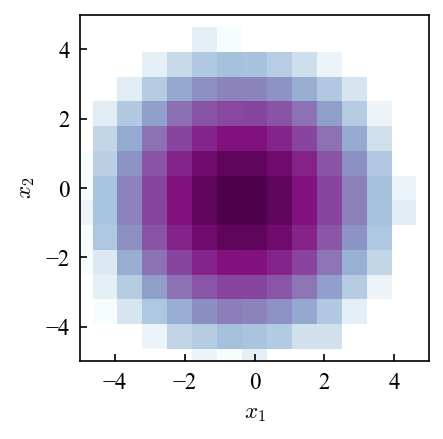

In [2]:
nr = 1000000
x1, x2 = np.random.normal(size=nr), np.random.normal(size=nr) 

#x2 = 0.8 * x1 + 0.3 * x2
# plot distribution of random numbers as a 2d histogram
plot_2d_dist(x1, x2, xlim=[-5,5], ylim =[-5,5], nxbins=15, nybins=15, 
             xlabel='$x_1$', ylabel='$x_2$', figsize=(3,3))

### <font color='blue'>Sequence of random number pairs as a random walk in 2D</font>


In [3]:
def plot_rand_track(x1, x2, figsize=(3,3), lw=0.1):
    plt.figure(figsize=figsize)
    plt.xlabel('$x_1$'); plt.ylabel('$x_2$')
    plt.plot(x1, x2, lw=lw)
    plt.show()

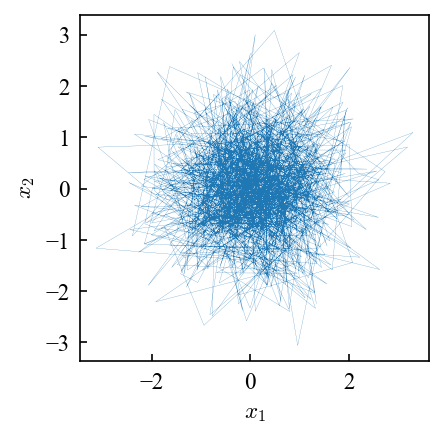

In [4]:
nr = 1000
x1, x2 = np.random.normal(size=nr), np.random.normal(size=nr) 

plot_rand_track(x1, x2)


### <font color='blue'>Bivariate (2D) Gaussian pdf $p_{\rm G}(x_1,x_2)$</font>


C:\Users\barre\ASTR 211 Winter\codes\plotting.py:344: UserWarning: Log scale: values of z <= 0 have been masked
  ax.contour(X, Y, H, linewidths=(1.0,0.75, 0.5, 0.25), colors='black', levels = sorted(lvls),


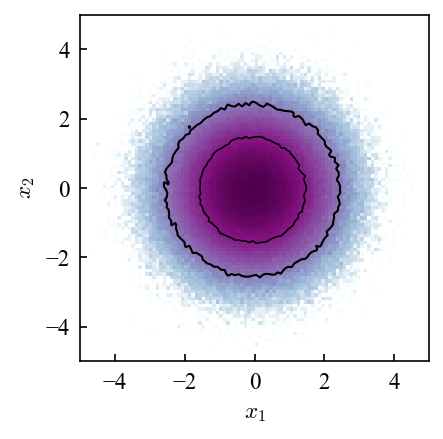

In [5]:
# define levels to plot (fractions of samples enclosed by the contours)
conflevs = [0.6827, 0.9545]
nr = 1000_000
x1, x2 = np.random.normal(size=nr), np.random.normal(size=nr) 

# plot distribution of random numbers as a 2d histogram
plot_2d_dist(x1, x2, xlim=[-5,5], ylim =[-5,5], nxbins=100, nybins=100, 
             clevs=conflevs,  xlabel='$x_1$', ylabel='$x_2$', figsize=(3,3))


### <font color='blue'>A generic way to sample multi-dimensional distributions: Markov Chain Monte Carlo (MCMC)</font> 
Nicholas Metropolis, Arianna Rosenbluth, Marshall Rosenbluth, Augusta Teller, and Edward Teller, used a novel method to produce samples in a Monte Carlo model of a
system of interacting particles approaching thermodynamic equilibrium in their 1953 paper <a href="http://adsabs.harvard.edu/abs/1953JChPh..21.1087M">"*Equation of State Calculations by Fast Computing Machines*"</a>. 

Despite the highly specific application of the original paper, the approach they used is generic and can be used to sample 
pdfs in any number of dimensions, even when normalization of the pdf is not known and cannot be easily computed.
This approach, developed and formalized further in the subsequent decades (particularly by W.K. Hastings in 1970) is now widely known as the MCMC. 

<center>
<img width=1200 src="https://astro.uchicago.edu/~andrey/classes/a211/img/metropolis_etal.png"></img>
</center>

<center>
    
### <font color='blue'>Generalizations by Canadian statistician Keith Hastings in 1970</font> 


<p>
<center>
    <img width=200 src="http://probability.ca/hastings/hastingsphoto.jpg"></img>
    
<p>
    
<center>
    <img width=900 src="http://astro.uchicago.edu/~andrey/classes/a211/img/hastings70.png"></img>

###  <font color='blue'>MCMC can be implemented in Python using 3 lines with NumPy</font>

In [6]:
import numpy as n
r=n.random;f=lambda p:-n.sum(p*p)/2;x=0
for d in r.randn(5000): x=x+d if f(x+d)-f(x)>n.log(r.rand()) else x


This code was <a href="https://twitter.com/hashtag/shortestmcmc?src=hash">tweeted</a>  by Dan Foreman-Mackey, developed of the `emcee` MCMC package about a decade ago (and this was done for an old much shorter character limit). 

###  <font color='blue'>Detailed balance condition defines how to make steps from $\mathbf{X}$ to $\mathbf{X}^\prime$ and from $\mathbf{X}^\prime$ to $\mathbf{X}$</font>
<p>
<center>
<img width=600 src="http://astro.uchicago.edu/~andrey/classes/a211/img/mcmc_ptr.png"></img>

### <font color='blue'>The cornerstone of MCMC sampling: detailed balance condition</font>

The number density of pdf samples at a given point $\mathbf{x}$ is equal to $\pi(\mathbf{x})$ by definition. Thus, the flux balance  can be achieved in the MCMC if we draw successive samples in such a way that transition probabilities, $p_{\rm tr}$, from $\mathbf{x}_i$ to $\mathbf{x}_{i+1}$ and from $\mathbf{x}_{i+1}$ to $\mathbf{x}_i$ satisfy:

$$\pi(\mathbf{x}_i)\,p_{\rm tr}(\mathbf{x}_{i+1}\vert\mathbf{x}_i)=\pi(\mathbf{x}_{i+1})\,p_{\rm tr}(\mathbf{x}_{i}\vert\mathbf{x}_{i+1}).$$ 

This is called *the detailed balance condition.* 

### <font color='blue'> Step acceptance probability distribution function</font>

The detailed balance condition after this cancellation is:

$$\pi(\mathbf{x})\,p_{\rm try}(\mathbf{x}^\prime\vert \mathbf{x})\,p_{\rm acc}(\mathbf{x}^\prime\vert \mathbf{x})=\pi(\mathbf{x}^\prime)\,p_{\rm try}(\mathbf{x}\vert \mathbf{x}^\prime)\,p_{\rm acc}(\mathbf{x}\vert \mathbf{x}^\prime).$$

so that 
$$p_{\rm acc}(\mathbf{x}^\prime\vert \mathbf{x})= \frac{\pi(\mathbf{x}^\prime)}{\pi(\mathbf{x})}\,p_{\rm acc}(\mathbf{x}\vert \mathbf{x}^\prime).\ \ \ \ \ \ \ \ (\star)$$

Let's assume that $p_{\rm acc}(\mathbf{x}\vert \mathbf{x}^\prime)=1$ if $\pi(\mathbf{x}^\prime)/\pi(\mathbf{x}) \geq 1$, i.e., *when the proposed step increases pdf, it is always accepted.*

When the proposed step decreases pdf, $\pi(\mathbf{x}^\prime)/\pi(\mathbf{x}) < 1$, accept the step with probability $p_{\rm acc}(\mathbf{x}\vert \mathbf{x}^\prime)=\pi(\mathbf{x}^\prime)/\pi(\mathbf{x})$. 

Then, it is easy to check that the condition $(\star)$ is satisfied. 

###  <font color='blue'>Acceptance probability "unpacked"</font>

What this means is that we on average should accept a fraction of 
$$
p_{\rm acc}(\mathbf{x}^\prime\vert\mathbf{x})=\min\left[\frac{\pi(\mathbf{x}^\prime)}{\pi(\mathbf{x})},1.0\right].
$$
 of proposed steps, and "reject" the rest.
 
***Rejection of a proposed step means that the next sample in the sequence is simply a duplicate of the sample at the current location $\mathbf{x}$***: $\mathbf{x}^\prime =\mathbf{x}$. We must add this duplicate to the sequence, because otherwise detailed balance condition is broken and we won't sample pdf correctly. 

###  <font color='blue'>The MCMC algorithm to draw random samples from $\pi(\mathbf{x})$</font>

Given an initial sample $\mathbf{x}_i$ drawn from $\pi(\mathbf{x})$ we generate next sample drawn from the same pdf using the following steps (arranged in a loop):

1. ***Step (evolution) proposal.*** Propose a new trial sample $\mathbf{x}^\prime$ by drawing it from whatever pdf $p_{\rm try}(\mathbf{x}^\prime\vert \mathbf{x}_i)$ we deem convenient, as long as $p_{\rm try}(\mathbf{x}^\prime\vert \mathbf{x}_i)=p_{\rm try}(\mathbf{x}_i\vert \mathbf{x}^\prime)$.


2. ***Acceptance or rejection of the proposed step.*** 
   For $\eta=\pi(\mathbf{x}^\prime)/\pi(\mathbf{x})$
   
   if $\eta \geq 1$, accept the proposed sample: $\mathbf{x}_{i+1}=\mathbf{x}^\prime$. 

   else, draw a random number, $u$, uniformly distributed in $[0,1)$ and assign the next sample in the sequence as
   
    $$\mathbf{x}_{i+1}=
 \begin{cases}
            \mathbf{x}^\prime, &  \mathrm{if}\ \ \ u<\eta,\\
            \mathbf{x}_i, &    \mathrm{otherwise\ },
    \end{cases}
$$

3. Check whether stopping criteria for generating a sequence are satisfied (more on these later). If not, go to step 1 to draw another sample.
    
    
A sequence of samples drawn using MCMC algorithm is usually called ***chain*** in the jargon of this method. 

###  <font color='blue'>pdf vs its natural log: example of the Gaussian pdf</font>


$$p_G(x) = \frac{1}{\sqrt{2\pi\sigma^2}}\,\exp\left[-\frac{(x-\mu)^2}{2\sigma^2}\right]$$



In [7]:
def gauss1d_pdf(x, mean=0., sigma=1.):
    assert(sigma>0)
    return np.exp(-0.5*((x-mean)/sigma)**2) / (np.sqrt(2*np.pi)*sigma)


In [8]:
np.log(gauss1d_pdf(50))


C:\Users\barre\AppData\Local\Temp\ipykernel_12596\1214130040.py:1: RuntimeWarning: divide by zero encountered in log
  np.log(gauss1d_pdf(50))


-inf

$$\ln p_G(x) = -\frac{1}{2}\,\ln\left(2\pi\sigma^2\right) - \frac{1}{2}\,\frac{(x-\mu)^2}{\sigma^2}=-\frac{1}{2}\,\left[\ln\left(2\pi\sigma^2\right) + \frac{(x-\mu)^2}{\sigma^2}\right]$$

In [9]:
def lngauss1d(x, mean=0., sigma=1.):
    '''Gaussian pdf with the mean, sigma evaluated at x'''
    return -0.5*(((x-mean)/sigma)**2 + np.log(2.*np.pi*sigma**2))


###  <font color='blue'>Acceptance condition for $\ln$ of pdf</font>

* Always accept the step from $\mathbf{x}$ to $\mathbf{x}^\prime$ if $\pi(\mathbf{x}^\prime)>\pi(\mathbf{x})$ or $\ln \pi(\mathbf{x}^\prime)>\ln \pi(\mathbf{x})$.



* Accept proposed step to location of smaller pdf $\pi(\mathbf{x}^\prime)<\pi(\mathbf{x})$ with the probability
$\pi(\mathbf{x}^\prime)/\pi(\mathbf{x})$. This means draw a random number $u$ from the uniform distribution in the range $[0,1)$ and accept the step if $u\leq\pi(\mathbf{x}^\prime)/\pi(\mathbf{x})$.
When we work with $\ln\pi(\mathbf{x})$, the corresponding condition is

$$\ln(u) \leq \ln\frac{\pi(\mathbf{x}^\prime)}{\pi(\mathbf{x})}=\ln\pi(\mathbf{x}^\prime) - \ln\pi(\mathbf{x}).$$



In [10]:
def metropolis_mcmc(x0, nsteps, step, logpdf, *args):
    x = x0 
    nparams = np.size(x0) # dimensionality of distribution we are sampling
    fnow = logpdf(x, *args) # compute current value of ln(pdf)
    
    chain = [] # initialize chain list
    for nstep in range(nsteps):
        xtry = x + np.random.uniform(-step, step, size=nparams)
        ftry = logpdf(xtry, *args)
        if ftry > fnow:
            x = xtry
            fnow = ftry
        else: 
            u = np.random.uniform()
            if np.log(u) < ftry - fnow:
                x = xtry
                fnow = ftry    
        chain.append(x)
    return np.array(chain)


In [11]:
def plot_pdf(xr, func=None, args=None, label='ITS method', 
             ylog=True,
             bins = 50, xlims=[], ylims=[], figsize=3):
    """
    wrapper convenience function for plotting  histogram of a sequence of floats xr
    and comparing it to a theoretical distribution given by func
    
    Parameters:
    -----------
    xr: 1d numpy array of floats, values in the sequence to plot
    func: Python function object handle
    args: list of arguments to the function
    other parameters are used for plotting
    """
    plt.figure(figsize=(figsize,figsize))
    if ylog: plt.yscale('log') # plot y-values on a logarithmic scale
    if ylims: plt.ylim(ylims) # set axis limits 
    if xlims: plt.xlim(xlims)
    # compute histogram values 
    hist, bins, patches = plt.hist(list(xr), density=True, bins=bins, label=label)
    binc = 0.5*(bins[1:] + bins[:-1]) # compute bin centers
    plt.plot(binc, func(binc, *args), lw=1.25, c='orangered', label='target pdf')
    plt.ylabel(r'$p(x)$') # label axis 
    plt.xlabel(r'$x$')
    plt.legend(loc='best', frameon=False, fontsize=3*figsize)
    plt.show()

The output tells us that $80\%$ of proposed trial steps were accepted. Note that this means that $20\%$ of the chain elements are duplicates, because sample location was duplicated if proposed step was not accepted. This is one of the reasons this is not the best method to use in 1d, where we can easily produce a sequence of Gaussian numbers using Box-Muller method with no duplicates. 

In [12]:
def plot_trace(x, figsize=3):
    try:
        nsteps, ndims = np.shape(x)[0], np.shape(x)[1]
    except:
        nsteps, ndims = np.shape(x)[0], 1
        
    plt.figure(figsize=(figsize,figsize))
    for d in range(ndims):
        if ndims == 1:
            plt.plot(np.arange(0,nsteps,1), x, lw=0.5, c='darkslateblue', label='d={:d}'.format(d))
        else:
            plt.plot(np.arange(0,nsteps), x[:,d], lw=0.5, c='darkslateblue', label='d={:d}'.format(d))
    plt.ylabel(r'$x$') # label axis 
    plt.xlabel(r'step number')
    plt.show()    

###  <font color='blue'>Trace plots, acceptance ratio, duplicates, independent samples</font>

Plots of values of sampled numbers as a function of step number are called ***trace plots*** in the MCMC jargon. The trace plot for the chain above is shown below

In [13]:
x0 = np.array([10.])
nsteps, step = 500_000, 1.
args= [0.,1.]
chain = metropolis_mcmc(x0, nsteps, step, lngauss1d, *args)

# compute the fraction of unique elements of the chain (fraction of trial steps that were accepted)
faccept = np.shape(np.unique(chain))[0] / nsteps
print(f'finished {nsteps:d} steps with acceptance ratio = {faccept:.4f}')


finished 500000 steps with acceptance ratio = 0.8037


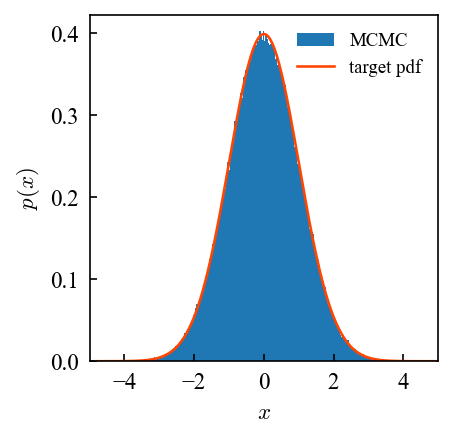

In [14]:
plot_pdf(chain.flatten(), func=gauss1d_pdf, args=[0,1], xlims=[-5,5], ylog=False, bins='auto', label='MCMC')


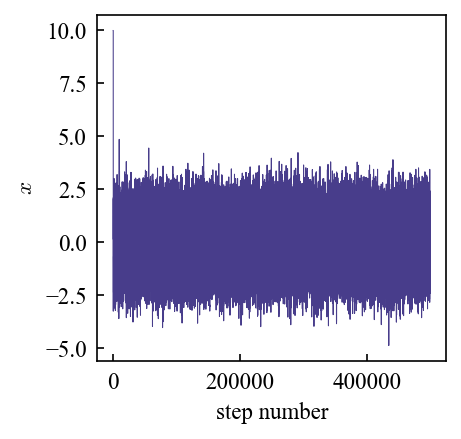

In [15]:
plot_trace(chain)


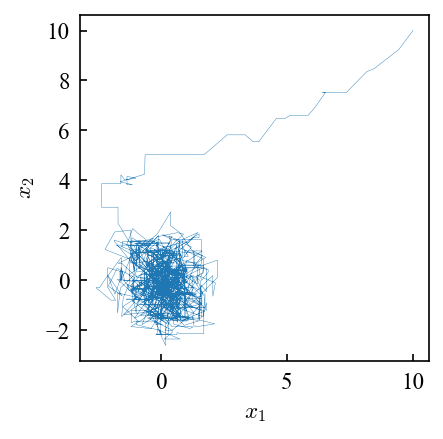

In [16]:
args= [0.,1.]
nplot = 1000

x1 = metropolis_mcmc(x0, nplot, step, lngauss1d, *args)
x2 = metropolis_mcmc(x0, nplot, step, lngauss1d, *args)
plot_rand_track(x1, x2, lw=0.2)


###  <font color='blue'>Trace plots: looking for a "hairy caterpillar"</font>

Plots of values of sampled numbers as a function of step number are called ***trace plots*** in the MCMC jargon. The trace plot for the chain above is shown below

We can see the sequence of first numbers that followed the initial value of $x_0=10$, which are very unlike for the Gaussian with zero mean and $\sigma=1$. We can see, for example, that in the remaining chain there are no values with $\vert x\vert>5$ that were realized after this initial sequence. This initial sequence of unlikely numbers is called *burn-in* of this chain. Usualy an effort is made to remove them.

The rest of the chain looks pretty good: the numbers bounce around zero sampling different parts of the distribution. 

The trace plot like this looks like a "hairy caterpillar" and an MCMC chain that looks like this likely sampled the distribution well. In the MCMC jargon it is said that the chain is ***converged.***

If we look at the first 1000 steps, this trace no longer looks like a "hairy caterpillar". 

### <font color='blue'>A more difficult/realistic case: sampling of the Rosenbrock "banana" distribution</font>

Rosenbrock distribution is described by the following equation in 2D (i.e. for two parameters $x$ and $y$): 

$$p_{\rm R}(x_1,x_2) = \exp\left[-c(b(x_2-x_1^2)^2 -(a-x_1)^2)\right], $$
    

which is often used for testing optimization and sampling algorithms, particularly with $a=1$, $b=100$ most often used. It has a global maximum at $(x_1,x_2)=(a,a^2)$ at which $p_{\rm R}(x_1,x_2)=1$, as is clear from the equation above. 

In [17]:
def lnrosenbrock(x, a=1., b=100., c=1.):
    """\ln of the Rosenbrock "banana" distribution
    x is a numpy vector of points in 2 or more dimensional space
    
    for a=1, the peak is at x = [1., 1., 1., ...]
    """
    return -c * sum(b*(x[1:]-x[:-1]**2.0)**2.0 + (a-x[:-1])**2.0)


In [18]:
from matplotlib.animation import FuncAnimation

def animate_1(i, scat, xp):
    '''
    produce scatter using particle coordinates at step i
    '''
    scat = scat.set_offsets(np.c_[xp[i,0], xp[i,1]])
    return scat

def animate_n(i, scat, xp):
    '''
    produce scatter using particle coordinates at step i
    '''
    scat = scat.set_offsets(np.c_[xp[i,0,:], xp[i,1,:]])
    return scat

def animate_track(xp=None, pmarkers='.', psizes=10, pcolors='slateblue', 
              xlabel=r'$x_1$', ylabel=r'$x_2$',
              interval=30, ssun = 50, lines2plot=None, grid=False, 
              xlims=[-1,1], ylims=[-1,1], figsize=(3,3)): 
    '''
    helper function to show animation of particle motion in 2D using pre-computed
    evolutionary tracks
    '''
    # set up figure parameters and axis labels
    fig, ax = plt.subplots(figsize=figsize)

    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.set(xlim=xlims, ylim=ylims)
    
    # define a grid of x and y for calculations and plotting
    xmin, xmax, ng = xlims[0], xlims[1], 100
    ymin, ymax = ylims[0], ylims[1]
    x = np.linspace(xmin, xmax, ng)
    y = np.linspace(ymin, ymax, ng)

    # generate a 2d grid of x and y points
    xg, yg = np.meshgrid(x, y)

    # form a single array of 2D vectors 
    x = np.vstack([xg.ravel(), yg.ravel()])

    # compute the Rosenbrock function and reshape the output into ng x ng grid for plotting
    rg = lnrosenbrock(x).reshape((ng,ng))
    ax = plot_color_map(xg, yg, np.log10(np.maximum(np.exp(rg),1e-300)), figax=(fig,ax), xlim=xlims, ylim=ylims, 
                   xlabel = xlabel, ylabel = ylabel, cmap='plasma', colorbar=True, 
                   contours=False, contcmap='plasma', cbar_label=r'$\log_{10} R$',
                   figsize=3.0)
    
    xshape = np.shape(xp)
    if len(xshape) == 2:
        scat = ax.scatter(xp[0,0] , xp[0,1], s=psizes, c=pcolors, marker=pmarkers, zorder=2) 
        anim_func = animate_1
    else:
        anim_func = animate_n
        scat = ax.scatter(xp[0,0,0] , xp[0,0,1], s=psizes, c=pcolors, marker=pmarkers, zorder=2) 
        
    if grid: ax.grid(ls='dotted', lw=0.25)
    anim = FuncAnimation(fig, anim_func, interval=interval, fargs=(scat, xp),
                         frames=np.shape(xp)[0], blit=False, repeat=True)
    #plt.draw()
    plt.tight_layout()
    plt.show()
    return anim

In [19]:
# define a grid of x and y for calculations and plotting
xmin, xmax, ng = -10, 10, 300
ymin, ymax = -50, 100
x = np.linspace(xmin, xmax, ng)
y = np.linspace(ymin, ymax, ng)

# generate a 2d grid of x and y points
xg, yg = np.meshgrid(x, y)

# form a single array of 2D vectors 
x = np.vstack([xg.ravel(), yg.ravel()])

# compute the Rosenbrock function and reshape the output into ng x ng grid for plotting
rg = lnrosenbrock(x).reshape((ng,ng))


The colormap below shows logarithm (base-10) of the 2D Rosenbrock function. The minimum of the function is at $[x,y]=[1,1]$. 

<Axes: xlabel='$x$', ylabel='$y$'>

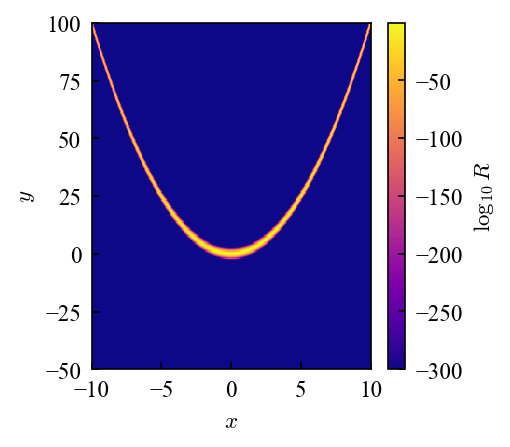

In [20]:
plot_color_map(xg, yg, np.log10(np.maximum(np.exp(rg),1e-300)), xlim=[xmin,xmax], ylim=[ymin,ymax], 
                   xlabel = r'$x$', ylabel = '$y$', cmap='plasma', colorbar=True, 
                   contours=False, contcmap='plasma', cbar_label=r'$\log_{10} R$',
                   figsize=3.0)

In [21]:
ndim = 2 # dimensionality of the distribution
nsteps = 100000 # number of steps to make
x0 = np.random.rand(ndim) # initial position
step = 1. # step size

args = [] # parameters of the Gaussian
# run simple MCMC 
chainr = metropolis_mcmc(x0, nsteps, step, lnrosenbrock, *args)


In [22]:
# define levels to plot (fractions of samples enclosed by the contours)
conflevs = [0.6827, 0.9545] # 1-sigma and 2-sigma contours

# plot distribution of MCMC samples as a 2d histogram with contours
# in the $x_0-x_1$ plane, where $x_0$ and $x_1$ are 2 Gaussian variables
# chain[:,0], chain[:,1] access sample values of two variables separately

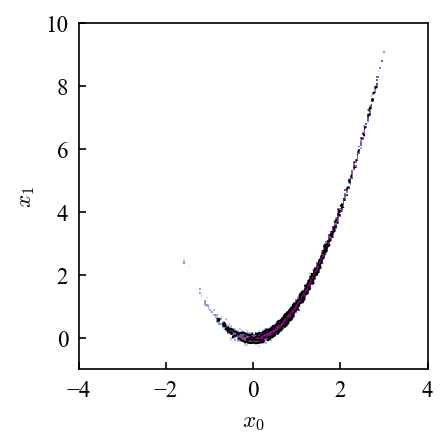

In [23]:
plot_2d_dist(chainr[:,0], chainr[:,1], xlim=[-4,4], ylim =[-1,10], nxbins=200, nybins=200, 
             clevs=conflevs,  xlabel='$x_0$', ylabel='$x_1$', figsize=(3,3))


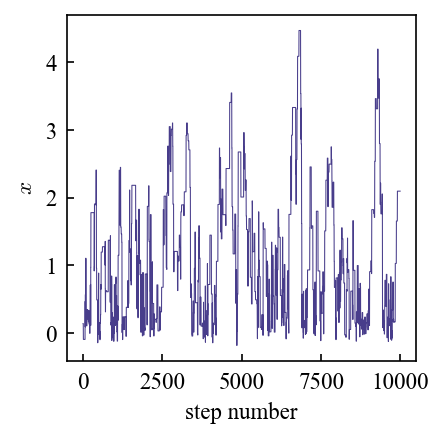

In [24]:
%matplotlib inline
plot_trace(chainr[:10000,1])

<IPython.core.display.Javascript object>


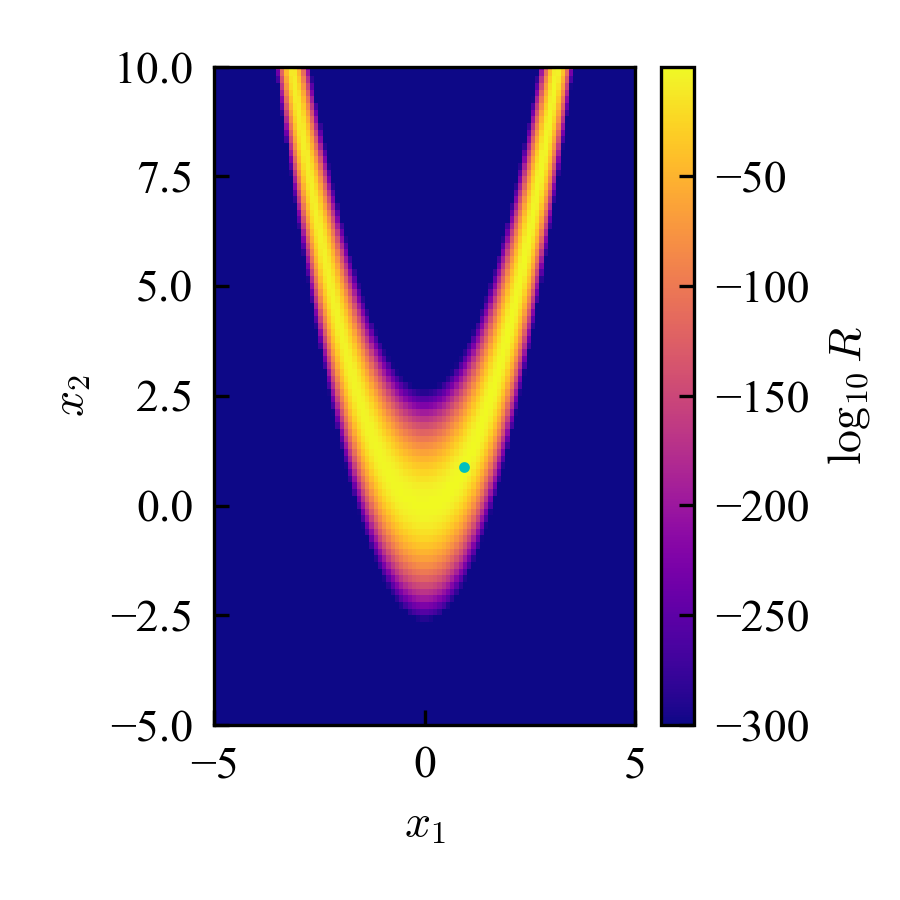

In [25]:
%matplotlib notebook

anim = animate_track(xp=chainr[::], interval=2, xlims=[-5,5], ylims=[-5,10], pcolors='c')
plt.show()

[A visual illustration.](https://github.com/chi-feng/mcmc-demo)

## <font color='blue'>Ensemble MCMC samplers</font>

The approach where multiple chains are generated and information about samples in different chains is exchanged is called *ensemble sampling* and is often used in the MCMC methods. The individual chains are called *population members* (DE MCMC) *ensemble walkers*  (in the GW 10 method, because sampling can be thought of as a walk in multi-d space).

The two ensemble we are discussing - DE MCMC and Goodman & Weare 2010 - use steps based on a different between randomly chosen population members (walkers). This makes step size adaptive and avoids the need to fine tune step size to the distribution. 


### <font color='blue'>Differential Evolution MCMC (DE MCMC)</font>

Differential Evolution MCMC was presented by Cajo Ter Braak in a [2006 paper](https://link.springer.com/article/10.1007/s11222-006-8769-1). It has the same basic structure as the DE method, but is different in the proposal step. 

Specifically, each iteration (step) consists of proposal to update the location vector $\mathbf{x}_i$ of member $i$ to a new location $\mathbf{x}^\prime_i$ as 

$$\mathbf{x}^\prime_i=\mathbf{x}_{i} + \gamma\,(\mathbf{x}_{r_2}-\mathbf{x}_{ r_1}) + e,$$

where $\mathbf{x}_{r_2}$ and $\mathbf{x}_{r_1}$ are the current location vectors of the two other members of the population different from $i$ and from each other.  This step is different from the steps used in the DE algorithm we considered because it uses current location of the member $\mathbf{x}_{i}$ in the calculation of the proposed step rather than another randomly chosen member. This is done to satisfy the detailed balance condition of the MCMC. 

$\gamma=2.38/\sqrt{d}$ where $d$ is the number of dimensions (parameters) of the pdf we sample, while $e$ is a random number drawn either from the uniform distribution $u$ defined on the interval $[-b,b]$ or from the $d$-dimensional Gaussian pdf with zero mean and dispersion $b$. Whatever pdf we use here, it must be symmetric around $0$ to satisfy the detailed balance condition of the MCMC. Regardless of the specific pdf, the $b$ value is set to be much smaller than the expected width of the distribution, for the Rosenbrock this can be say $b=10^{-3}$ or so. 


### <font color='blue'>Affine-invariant ensemble sampler of Goodman & Weare (2010)</font>
    
    
<a href="http://msp.org/camcos/2010/5-1/p04.xhtml">Goodman & Weare (2010)</a> have developed a simple MCMC sampling algorithm, which is efficient for distributions that exhibit strong degeneracies (narrow ridges in the pdf) or pdfs with multiple peaks. 


* In this method a step from location $\mathbf{x}_i$ to $\mathbf{x}_{i+1}$ is proposed as a *stretch* move: $\mathbf{x}_{i}^{\prime}=\mathbf{x}_{j}+z_r(\mathbf{x}_{i}-\mathbf{x}_j)$, where $\mathbf{x}_{j}$ is the current location of *another* randomly chosen walker (but not the current one we are updating) and $z_r$ is  a random number drawn from the pdf $g(z)= 1/\sqrt{z}$ for $z\in[1/a,a]$ interval and $g(z)=0$ outside this interval, where GW10 suggest $a=2$. 


* The proposed stretch move is then accepted with probability $p_{\rm acc}={\rm min}[1.0,z_r^{D-1}\pi(\mathbf{x}_i^{\prime})/\pi(\mathbf{x}_i)]$, where $\pi$ is the target pdf the chain is supposed to sample and $D$ is the number of components of $\mathbf{x}$ (i.e., the number of dimensions of the pdf we are sampling; e.g., for the $D=2$ for a 2D Gaussian).  

In this method, one initializes a number of walkers (this is why it is called *ensemble sampler*) distributed with a multi-variate Gaussian probability around a starting point. Then MCMC chain is constructed in a way similar to the Metropolis algorithm: proposing a step, estimating probability at the proposed location, and then accepting the step with an acceptance probability. The difference from the Metropolis MCMC is in the way the step is proposed and how acceptance probability is calculated:


### <font color='blue'>"Stretch" move in the Goodman & Weare (2010) algorithm</font>
    
<center>
<img width=500 src="https://astrobites.com/wp-content/uploads/2012/02/stretchmove-300x204.png"></img>

### <font color='blue'>Why do ensemble sampling algorithms improve the Metropolis MCMC?</font>


###  <font color='blue'>GW10 algorithm is implemented in the emcee MCMC package</font>

GW10 algorithm is implemented in the most popular MCMC package in astronomy <a href="https://emcee.readthedocs.io/en/v2.2.1/"><tt>emcee</tt></a>. 

To install it, do

    pip install emcee
    
in the Anaconda command prompt or linux/MacOS shell.

In [26]:
import emcee

ndim, nwalkers, nsteps = 1, 10, 50000
# initialize walkers
p0 = np.random.rand(ndim * nwalkers).reshape((nwalkers, ndim))

# initialize MCMC sample
sampler = emcee.EnsembleSampler(nwalkers, ndim, lngauss1d, args=[0.,1.])

# run for a given nsteps
dummy = sampler.run_mcmc(p0, nsteps)

# get chain
chaingw = sampler.chain

ModuleNotFoundError: No module named 'emcee'

In [27]:
plot_pdf(chaingw.flatten(), func=gauss1d_pdf, args=[0,1], xlims=[-5,5], ylog=False, bins='auto', label='')

NameError: name 'chaingw' is not defined

In [28]:
np.unique(chaingw[2,:]).size/50000

NameError: name 'chaingw' is not defined

<IPython.core.display.Javascript object>


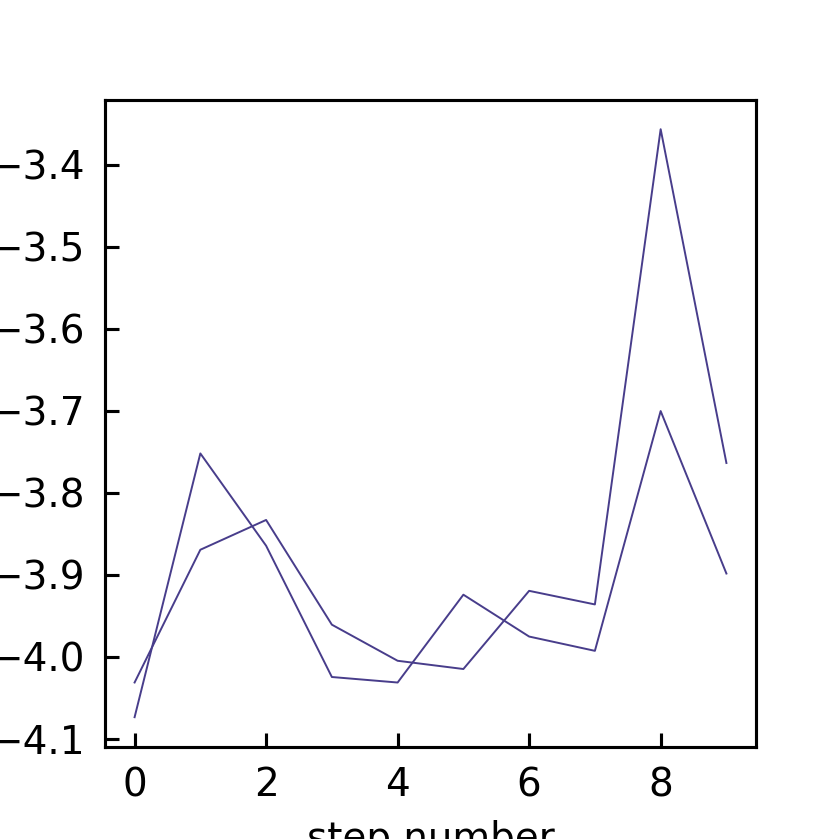

In [359]:
# plot trace of a single walker

plot_trace(chaingw[2,:2000])

###  <font color='blue'>Sample $\ln$ of Rosenbrock pdf with GW10 algorithm</font>


In [291]:
import emcee

ndim, nwalkers, nsteps = 2, 10, 5000

# initialize walkers
p0 = np.random.normal(-4, 0.1, ndim * nwalkers).reshape((nwalkers, ndim))

# initialize MCMC sample
sampler = emcee.EnsembleSampler(nwalkers, ndim, lnrosenbrock, args=[])

# run for a given nsteps
dummy = sampler.run_mcmc(p0, nsteps)

# get chain
chaingw = sampler.get_chain()


<IPython.core.display.Javascript object>


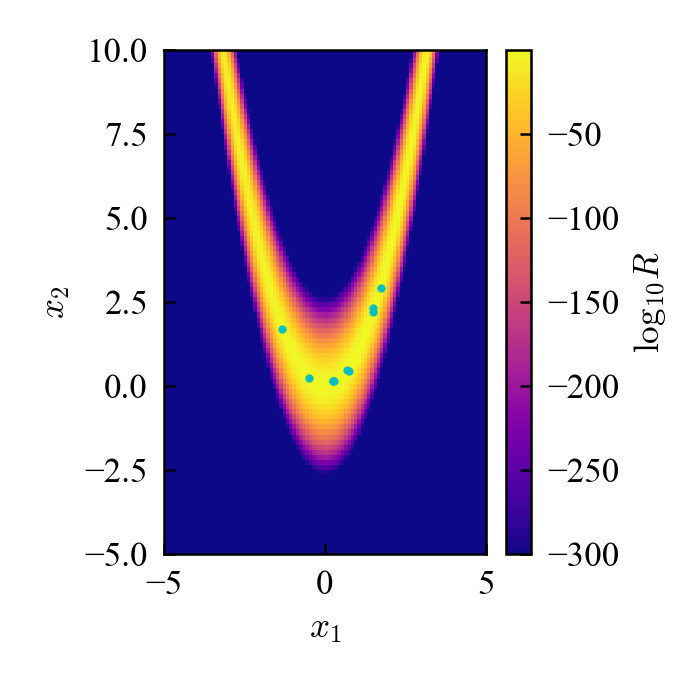

In [251]:
%matplotlib notebook
anim = animate_track(xp=np.rot90(chaingw, axes=(2,1)), 
                     interval=100, xlims=[-5,5], ylims=[-5,10], pcolors='c')


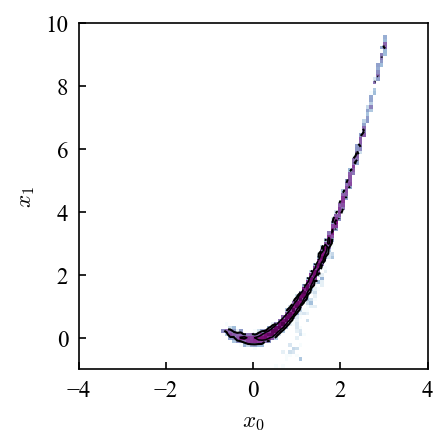

In [292]:
%matplotlib inline 
# define levels to plot (fractions of samples enclosed by the contours)
conflevs = [0.6827, 0.9545] # 1-sigma and 2-sigma contours

x = chaingw[:,:,0].flatten()
y = chaingw[:,:,1].flatten()

plot_2d_dist(x, y, xlim=[-4,4], ylim =[-1,10], nxbins=100, nybins=100, 
             clevs=conflevs,  xlabel='$x_0$', ylabel='$x_1$', figsize=(3,3))

In [299]:
%matplotlib inline

x = chaingw[:,0]
np.unique(x).size/x.size

0.4146

In [296]:
chaingw.shape

(5000, 10, 2)

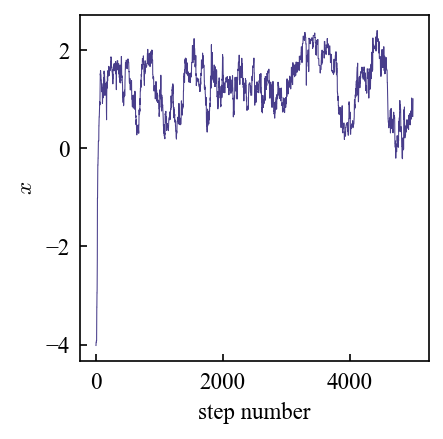

In [301]:
plot_trace(chaingw[:10000,0,0].flatten())


### <font color='blue'>Skeleton of the MCMC function based on the DE function</font>


In [49]:

def mcmc(logpdf, x0, nsteps=10000, args=[]):
    '''
    Differential Evolution implementation that is not fully vectorized
    '''w
    npop, nd = np.shape(x0)
    xnow = np.copy(x0)
    xnext = np.copy(xnow)
    
    fnow = np.zeros(npop)
    for i in range(npop):
        fnow[i] = logpdf(xnow[i], *args)
    
    fnext = np.zeros_like(fnow)
    chain = []

    for step in range(nsteps):
               
        for i in range(npop):
            #xtry = proposal step
            ftry = logpdf(xtry, *args)
            #accept = acceptance condition
#             if accept:
#                 xnext[i] = xtry
#                 fnext[i] = ftry
#             else:
#                 xnext[i] = xnow[i]
#                 fnext[i] = fnow[i]
                
        xnow = np.copy(xnext)
        fnow = np.copy(fnext)
        chain.append(np.copy(xnow).T)
        
    return np.array(chain)

### Recommended

* Illustrative <a href="http://chi-feng.github.io/mcmc-demo/">visualizations of MCMC methods at work</a>.

## <font color='blue'>Using MCMC for statistical inference of model parameter values</font>


### <font color='blue'>Specific example: linear model</font>

We will consider a simple, but commonly encoutered in practice case of the *linear model*: $y=bx +c + \epsilon$, where $\epsilon$ is the random number drawn from the Gaussian pdf with zero mean and standard deviation $e$. 

This model assumes that uncertainties of measurements in both $x$ and $y$ measurements, $\sigma_x$ and $\sigma_y$, can be described by Gaussian pdfs. In this case, the overall uncertainty if the difference between measurement $(x,y)$ and model prediction $y_{\rm m}=bx + c$ is the uncertainty of the residual $r=y-bx-c$, which by propagation of error is $\sigma\approx \sqrt{\sigma_y^2 + b^2\sigma_x^2}$. 

For the entire set of measurement the log of the likelihood is 

\begin{eqnarray}
\ln L(\vec{y}\vert b,c) &=& n\ln{1\over \sqrt{2\pi}} - \sum\limits_{i=0}^{n-1}\ln\sigma_{i}-{1\over 2}\,\sum\limits_{i=0}^{n-1}\frac{(y_i-y_m)^2}{\sigma_{i}^2}\\ &=&n\ln{1\over \sqrt{2\pi}} - {1\over 2} \,\sum\limits_{i=0}^{n-1}\ln\sigma_{i}^2-{1\over 2} \,\sum\limits_{i=0}^{n-1}\left(\frac{r_i}{\sigma_{i}}\right)^2,
\end{eqnarray}


### <font color='blue'>Mock data set for testing the model inference</font>


The functions below generate a mock data set that follows a linear relation with specified slope and intercept (<tt>btrue, ctrue</tt>) and uncertainties in both $x$ and $y$ variables. Given that we know what the true values of $b$ and $c$ are for the mock dataset generated in this way, we can use the data to test the model. 

In [302]:
def generate_mock_data(xlims, ex, ey, ebias=1., btrue=3, ctrue=3.481, nr = 2000):
    xr = np.random.uniform(xlims[0], xlims[1], size=nr) 

    exr = np.random.normal(scale=ex, size=nr)
    eyr = np.random.normal(scale=ey, size=nr)

    yr = btrue * xr + ctrue + eyr*ebias 
    xr = xr + exr
    
    return xr, exr, yr, eyr

In [303]:
def plot_mock_data(xr, yr, exr=None, eyr=None, 
                   btrue=None, ctrue=None, figsize=(5,5)):
    # plot mock data
    plt.figure(figsize=figsize)
    plt.errorbar(xr, yr, xerr=exr, yerr=eyr, fmt='o', alpha=0.5, color='darkslateblue')
    plt.xlabel(r'x')
    plt.ylabel('y')
    xf = np.linspace(xr.min(), xr.max(), 10)
    plt.plot(xf, btrue * xf + ctrue, '--', c='orangered', label='true model')
    plt.legend(loc='best')
    plt.show()

Function below computes $\ln L$ given by expression above for input values of $c$ and $b$ and data set passed through <tt>args</tt>

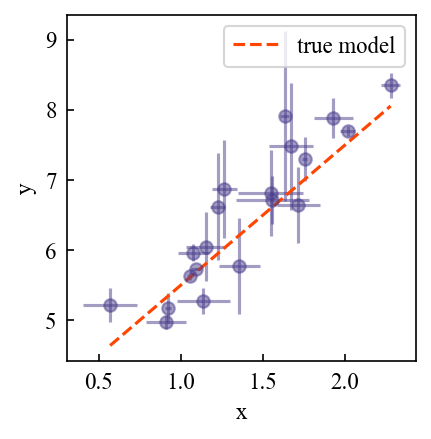

In [304]:
%matplotlib inline
# generate mock data with a given slope and intercept
nr = 20 # number of data points to generate
btrue, ctrue = 2., 3.5
ex, ey = 0.1, 0.5
xr, exr, yr, eyr = generate_mock_data([0.7, 2.5], ex, ey, ebias=1., btrue=btrue, ctrue=ctrue, nr=nr)

plot_mock_data(xr, yr, exr=exr, eyr=eyr, btrue=btrue, ctrue=ctrue, figsize=(3,3))

\begin{eqnarray}
\ln L(\mathbf{y}\vert b,c) &=& n\ln{1\over \sqrt{2\pi}} - \sum\limits_{i=0}^{n-1}\ln\sigma_{i}-{1\over 2}\,\sum\limits_{i=0}^{n-1}\frac{(y_i-y_m)^2}{\sigma_{i}^2}\\ &=&n\ln{1\over \sqrt{2\pi}} - {1\over 2} \,\sum\limits_{i=0}^{n-1}\ln\sigma_{i}^2-{1\over 2} \,\sum\limits_{i=0}^{n-1}\left(\frac{r_i}{\sigma_{i}}\right)^2,
\end{eqnarray}

$\sigma_i= \sqrt{\sigma_{i,y}^2 + b^2\sigma_{i,x}^2}$


In [314]:
def loglin_like(p, *args):
    x, y, sigx, sigy = args[:4]
    c, b = p
    sigtot2 = sigy**2 + (b*sigx)**2

    # 1/sqrt(2.*pi) factor can be omitted from the likelihood because it does not depend on model parameters
    return np.sum(-0.5 * (np.log(sigtot2) + (y - c - b*x)**2 / sigtot2))


In [328]:
def loglin_prior(p, *args):
    cmin, cmax = args[4]
    bmin, bmax = args[5]
    c, b = p
    if (c < cmin) or (c > cmax) or (b < bmin) or (b > bmax):
        return -1000.
    else:
        return 0. # unnormalized uniform function = 1 within [cmin,cmax] and [bmin, bmax]
    

In [ ]:
def loglin_posterior(p, *args):
    return loglin_like(p, *args) + loglin_prior(p, *args)


In [314]:

def loglin_like(p, *args):
    '''
    ln of the likelihood pdf

    Parameters:
        p is array of parameters p=[c,b]
        args: iterable (list or tuple) containing arrays
        x, y, sigx, sigy, [cmin, cmax], [bmin, bmax]
    Returns:
        ln of the likelihood function
    '''
    x, y, sigx, sigy = args[:4]
    c, b = p
    sigtot2 = sigy**2 + (b*sigx)**2

    # 1/sqrt(2.*pi) factor can be omitted from the likelihood because it does not depend on model parameters
    return np.sum(-0.5 * (np.log(sigtot2) + (y - c - b*x)**2 / sigtot2))

In [328]:
def loglin_prior(p, *args):
    '''
    ln of the uniform prior pdf in the slope and intercept c and b

    Parameters:
        p is array of parameters p=[c,b]
        args: iterable (list or tuple) containing arrays
        x, y, sigx, sigy, [cmin, cmax], [bmin, bmax]
    Returns:
        float: ln(prior pdf)
    '''
    cmin, cmax = args[4]
    bmin, bmax = args[5]
    c, b = p
    if (c < cmin) or (c > cmax) or (b < bmin) or (b > bmax):
        return -1000.
    else:
        return 0. # unnormalized uniform function = 1 within [cmin,cmax] and [bmin, bmax]

In [ ]:
def loglin_posterior(p, *args):
    '''
    ln of the posterior pdf, calls the function above to compute
    ln(pi) = ln(l * prior) = ln(l) + ln(prior)

    Returns:
        float: ln(posterior pdf)
    '''
    return loglin_like(p, *args) + loglin_prior(p, *args)

In [315]:
ndim = 2
nsteps = 50000
x0 = [3., 2.] # start at the true values of the parameters
step = 0.1

xr, exr, yr, eyr = generate_mock_data([0.7, 2.5], ex, ey, ebias=1., btrue=btrue, ctrue=ctrue, nr=20)

args = [xr, yr, exr, eyr]
chain = metropolis_mcmc(x0, nsteps, step, loglin_like, *args)

Plot parameter values sampled in the MCMC chain in the $c-b$ plane as 2D histogram. The contours are defined by the values in the list <tt>conflevs</tt>, which are chosen to encose $68.27\%$ and $95.45\%$ of samples, which approximately corresponds to $1-\sigma$ and $2-\sigma$ of the 1D Gaussian pdf. Such contours are referred to as $1-\sigma$ and $2-\sigma$ contours. 

The true values of the slope and intercept are shown by red cross. We get unbiased values of the parameters if the sampled likelihood pdf is within these contours. If  regenerate the mock data set again and again and redo the sampling each time, we should see that the true value should be within $1\sigma$ contour about $68.25\%$ of the time (try this!). 

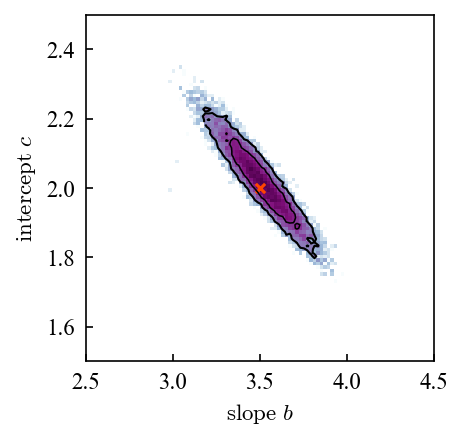

In [316]:
conflevs = [0.6827, 0.9545]

plot_2d_dist(chain[:,0], chain[:,1].flatten(), xlim=[2.5,4.5], ylim =[1.5,2.5], 
             nxbins=100, nybins=100, clevs=conflevs, xpmax=ctrue, ypmax=btrue, 
             ylabel=r'${\rm intercept}\ c$', xlabel=r'${\rm slope}\ b$', figsize=(3,3))

We can see that distribution of $b$ and $c$ values looks like a 2-dimensional Gaussian. The true value of the parameters is close to the peak of the distribution. This means that we *infered* parameter values from the mock data without bias. The values of $b$ and $c$ of the chain element that maximizes the likelihood can be taken as "best-fit" parameter values. If the distribution is close to Gaussian (symmetric) a simple median of the values can be used as a parameter estimates. These will be somewhat different from true values because parameter inference has uncertainty that is reflected in the width of the distribution above.  

The confidence intervals of $b$ and $c$ can be obtained by determined by finding their value range that encloses a given fraction of the samples. For example, contours in the plot above enclose $68.27%$ and $95.45%$ of the samples are this is what usually referred to as $1-\sigma$ and $2-\sigma$ contours (one can add more contours if outer parts of the distribution are well sampled. 

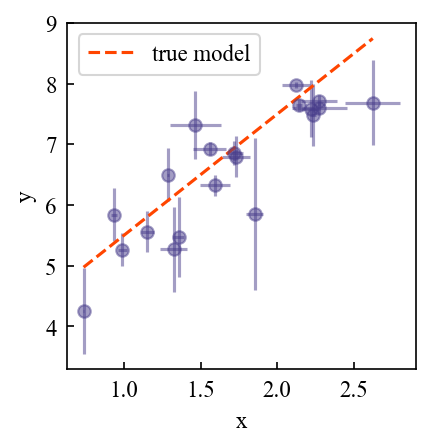

In [309]:
plot_mock_data(xr, yr, exr=exr, eyr=eyr, btrue=btrue, ctrue=ctrue, figsize=(3,3))

In [317]:
def clims(a):
    '''
    compute confidence limits given a given percentile a
    '''
    x1 = 0.5*(100.-a)
    return x1, a + x1

def chain_stats(x, param_name='x'):
    """
    print mean, median, and confidence intervals for samples for a chain of sampled values
    for a *single* parameter
    """
    xmed = np.median(x); xm = np.mean(x); xsd = np.std(x)
    a = 68.268; 
    x1, x2 = clims(a)
    xcfl11 = np.percentile(x,x1); xcfl12 = np.percentile(x,x2)
    a = 95.452
    x1, x2 = clims(a)
    xcfl21 = np.percentile(x,x1); xcfl22 = np.percentile(x,x2)
    dashedline = '-------'
    print('============ statistics for the {:s} ============'.format(param_name))
    print('mean, median = %.3f, %.3f, st.dev=%.4f'%(xm, xmed, xsd))
    print('68 perc interval = %.3f, %.3f'%(xcfl11, xcfl12))
    print('95 perc interval = %.3f, %.3f'%(xcfl21, xcfl22))


In [318]:
chain_stats(chain[:,0], param_name='intercept')
chain_stats(chain[:,1], param_name='slope')

============ statistics for the intercept ============
mean, median = 3.519, 3.519, st.dev=0.1308
68 perc interval = 3.389, 3.651
95 perc interval = 3.250, 3.775
============ statistics for the slope ============
mean, median = 2.023, 2.023, st.dev=0.0828
68 perc interval = 1.940, 2.105
95 perc interval = 1.861, 2.194


Plot parameter values sampled in the MCMC chain in the $c-b$ plane as 2D histogram. The contours are defined by the values in the list <tt>conflevs</tt>, which are chosen to encose $68.27\%$ and $95.45\%$ of samples, which approximately corresponds to $1-\sigma$ and $2-\sigma$ of the 1D Gaussian pdf. Such contours are referred to as $1-\sigma$ and $2-\sigma$ contours. 

The true values of the slope and intercept are shown by red cross. We get unbiased values of the parameters if the sampled likelihood pdf is within these contours. If  regenerate the mock data set again and again and redo the sampling each time, we should see that the true value should be within $1\sigma$ contour about $68.25\%$ of the time (try this!). 

### <font color='blue'>Importance of the starting point and burn-in</font> 

You may have noticed that the MCMC sampling above was started at the true values of the parameters. 
This is the luxury we may not have. 
    
Recalculation below shows what happens when we start at values pretty far from the true ones. 

In [323]:
ndim = 2
nsteps = 100000
x0 = [0, 1.] # start at a random point
step = 0.1

 # ranges of c, b for uniform pdf
cmin, cmax = [1., 4.]
bmin, bmax = [2., 5.]

args = [xr, yr, exr, eyr, [bmin,bmax], [cmin,cmax]]
chain = np.asarray(metropolis_mcmc(x0, nsteps, step, loglin_like, *args))

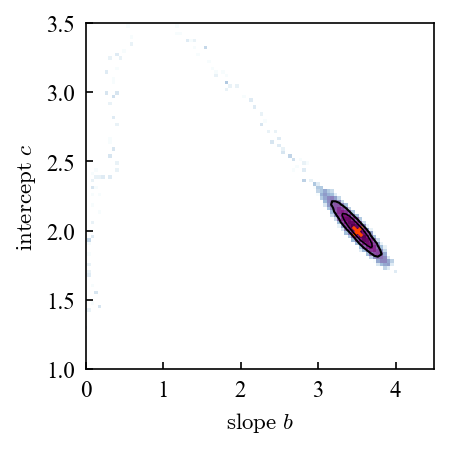

In [324]:
conflevs = [0.6827, 0.9545]

plot_2d_dist(chain[:,0], chain[:,1].flatten(), xlim=[0,4.5], ylim =[1.,3.5], 
             nxbins=100, nybins=100, clevs=conflevs, xpmax=ctrue, ypmax=btrue, 
             ylabel=r'${\rm intercept}\ c$', xlabel=r'${\rm slope}\ b$', figsize=(3,3))

We can see that the chain recovers, but there is a fairly sizeable initial portion of the chain where samples do not follow the Gaussian pdf. This is the "burn-in" part of the chain. If it is not removed, it can potentially bias our estimates of quantities such as mean values of parameters. 

Burn-in can be minimized if we start from the initial values of parameters that are close to the maximum of the distribution. Thus, it helps to know where this maximum is. Finding extrema of functions is handled by ***optimization methods***, which we discussed, and as was shown above.

Here is an example using SciPy's differential evolution function. Here we define minus log likelihood  because we will use function that finds minimum to find maximum:

In [325]:
def minus_loglin_posterior(x, *args):
    '''
    define minus log likelihood because we will use function that finds minimum to find maximum
    '''
    return -loglin_posterior(x, *args)

In [326]:
from scipy.optimize import differential_evolution

args = [xr, yr, exr, eyr, [bmin,bmax], [cmin,cmax]]
bounds = [[1,5],[1,5]]

res = differential_evolution(minus_loglin_posterior, bounds=bounds, args=args)

print(f'The best fit intercept and slope values: c = {res.x[0]:.3f}, b = {res.x[1]:.3f}')

The best fit intercept and slope values: c = 3.533, b = 2.014


This illustrates that just knowing the values that maximize likelihood is not particularly meaningful: intercept and slope are not exactly equal to their true values, but we don't know whether this means that our inference is wrong or is this because these values are uncertain due to uncertainties in the data. To answer this question we need to estimate confidence limits on the parameters as was shown above. 

### <font color='blue'>Homework 5 assignment</font> 

* Implement posterior pdf for supernova data for a supernova distance modulus model with 5 parameters. Use DE minimization to find the values of the model parameters that maximize the likelihood. 


* Implement and test either DE MCMC or Affine-invariant MCMC algorithm. Make sure you submit your HW 4, so I can distribute solutions to you. 


* Use your implementation (or emcee code) to obtain MCMC samples of the likelihood pdf and to get confidence contours for the mean density of matter and dark energy in the Universe. 

